# Lead Scoring — ¿qué MQLs vale la pena perseguir?

Entrenamos un clasificador (XGBoost) para priorizar los Marketing Qualified Leads (MQL) según su probabilidad de convertirse en seller. Es el primer eje analítico del proyecto (ver README).

**Target elegido: conversión**, no revenue. De los 842 MQLs que llegaron a `closed_deals`, 462 (55%) nunca vendieron nada, y las columnas de valor declarado (`declared_monthly_revenue`, `has_company`, etc.) tienen hasta ~92% de nulos — no alcanza todavía para un target de "alto valor" confiable. Conversión, en cambio, está bien poblada (8.000 MQLs, 842 positivos, ~10.5%) y usa solo features que existen para *todos* los leads al momento de llegar (`origin`, `landing_page_id`, `first_contact_date`), sin fugas de información del futuro.

## 1. Carga de datos y target

In [1]:
import os
import sys

# Mismo patron que en EDA_1.ipynb: el cwd del kernel puede ser notebooks/
# o la raiz del repo, segun la herramienta.
project_root = '.' if os.path.isdir('src') else '..'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import xgboost as xgb
import shap
import joblib

sns.set_theme(style="whitegrid")

from src.data import load_raw_tables

tables = load_raw_tables()
mql = tables['mql']
closed_deals = tables['closed_deals']

mql['converted'] = mql['mql_id'].isin(closed_deals['mql_id']).astype(int)

print(f"MQLs: {len(mql)} | Convertidos: {mql['converted'].sum()} ({mql['converted'].mean():.1%})")

MQLs: 8000 | Convertidos: 842 (10.5%)


## 2. `contact_month` no es estacionalidad — es censura del período de recolección

Antes de armar features vale la pena mirar la ventana temporal de los datos. Los MQL van de 2017-06-14 a 2018-05-31 (12 meses exactos), pero el primer `won_date` registrado en `closed_deals` es recién el 2017-12-05: ningún deal figura como ganado antes de esa fecha, sin importar cuándo se contactó al lead.

Eso significa que un lead contactado en julio de 2017 tuvo mucho menos ventana de registro para aparecer como conversión que uno contactado en enero de 2018 — no porque haya convertido menos, sino porque el dataset no llegó a registrar ese cierre. La tasa de conversión por mes de contacto lo muestra clarísimo:

In [2]:
closed_deals['won_date'] = pd.to_datetime(closed_deals['won_date'])
mql['first_contact_date'] = pd.to_datetime(mql['first_contact_date'])

print(f"MQLs: {mql['first_contact_date'].min().date()} a {mql['first_contact_date'].max().date()}")
print(f"Primer won_date registrado: {closed_deals['won_date'].min().date()}")
print()

conv_by_month = (
    mql.assign(contact_ym=mql['first_contact_date'].dt.to_period('M'))
    .groupby('contact_ym')
    .agg(n_leads=('mql_id', 'size'), conversion_rate=('converted', 'mean'))
)
conv_by_month

MQLs: 2017-06-14 a 2018-05-31
Primer won_date registrado: 2017-12-05



,n_leads,conversion_rate
contact_ym,,
2017-06,4,0.000000
2017-07,239,0.008368
2017-08,386,0.023316
2017-09,312,0.022436
2017-10,416,0.033654
2017-11,445,0.040449
2017-12,200,0.055000
2018-01,1141,0.133216
2018-02,1028,0.144942


La tasa salta de ~1-4% en 2017 a ~13-15% apenas entramos a 2018 — un salto demasiado brusco y demasiado alineado con el cambio de año para ser estacionalidad comercial real. Como la ventana completa son exactamente 12 meses, `contact_month` ∈ {1..5} equivale casi siempre a "2018" y {6..12} a "2017": una feature construida así no aprende ciclos de negocio, aprende en qué mitad del período de recolección cayó el lead. Es censura del proceso de recolección de datos, no señal.

**Arreglo:** acotamos el universo a los leads con la ventana de conversión abierta (`first_contact_date >= 2018-01-01`) y de acá en más entrenamos y evaluamos solo sobre 2018, con un split temporal (train enero-marzo, test abril-mayo) en vez de aleatorio — así el modelo se evalúa tal como se usaría en producción: puntuando leads futuros con un modelo entrenado en el pasado, sin la ventana desigual de por medio.

In [3]:
n_before = len(mql)
mql = mql[mql['first_contact_date'] >= '2018-01-01'].copy()
print(f"MQLs: {n_before} -> {len(mql)} tras acotar a 2018 "
      f"({mql['converted'].sum()} convertidos, {mql['converted'].mean():.1%})")

MQLs: 8000 -> 5998 tras acotar a 2018 (781 convertidos, 13.0%)


## 3. Feature engineering

Todas las features vienen de `mql`, la única tabla poblada para el universo completo de leads (incluidos los que nunca convirtieron):

- `origin`: categórica (10 valores + nulos, los completamos como `"unknown"`).
- `landing_page_id`: tiene **495 valores únicos**. Probamos dejarla como categórica nativa de XGBoost y el modelo memorizó de más — la reemplazamos por su frecuencia de aparición (`lp_freq`), que captura "página popular vs. de nicho" sin darle al árbol 495 formas de partir los datos.
- `first_contact_date`: extraemos solo día de la semana (`contact_dayofweek`). No extraemos mes: vimos en la sección anterior que, aún acotado a 2018, el mes de contacto determina directamente si un lead cae en train o en test una vez que el split pasa a ser temporal (sección 4) — como feature sería tramposa, porque el modelo nunca vería en train los valores de mes que después tiene que puntuar en test.

In [4]:
mql['contact_dayofweek'] = mql['first_contact_date'].dt.dayofweek
mql['origin'] = mql['origin'].fillna('unknown').astype('category')

landing_page_freq = mql['landing_page_id'].value_counts()
mql['lp_freq'] = mql['landing_page_id'].map(landing_page_freq)

feature_cols = ['origin', 'contact_dayofweek', 'lp_freq']
X = mql[feature_cols]
y = mql['converted']

X.dtypes

origin               category
contact_dayofweek       int32
lp_freq                 int64
dtype: object

## 4. Train / test split

Split temporal en vez de aleatorio: entrenamos con leads de enero-marzo 2018 y evaluamos con los de abril-mayo 2018. Es lo conceptualmente correcto para este problema — en producción el modelo puntúa leads que todavía no pasaron, entrenado con leads del pasado — y de paso evita cualquier fuga temporal residual. A diferencia del split aleatorio anterior, acá no hay estratificación: la tasa de conversión de train y test queda un poco distinta, como pasaría en producción.

In [5]:
train_mask = mql['first_contact_date'] < '2018-04-01'
test_mask = ~train_mask

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train (ene-mar 2018): {len(X_train)} filas ({y_train.mean():.1%} positivos)")
print(f"Test  (abr-may 2018): {len(X_test)} filas ({y_test.mean():.1%} positivos)")

Train (ene-mar 2018): 3343 filas (14.0% positivos)
Test  (abr-may 2018): 2655 filas (11.8% positivos)


## 5. Selección de hiperparámetros

Con pocas filas de train (3.343) y clases desbalanceadas, un árbol sin restricciones memoriza en vez de generalizar (lo vimos con `landing_page_id` crudo: AUC train 0.864 vs test 0.665). Para evitarlo, buscamos la combinación de `max_depth`, `min_child_weight` y `reg_lambda` — los tres parámetros que más controlan qué tan libre está el árbol de ajustarse al ruido — que mejor generaliza, medida con `GridSearchCV` y `StratifiedKFold` de 5 folds **sobre train únicamente**. El test no participa de esta selección: se toca una sola vez, en la sección 7, para reportar la métrica final del modelo ya elegido.

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
)

param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [3, 5, 10, 20],
    'reg_lambda': [1, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    base_model, param_grid, scoring='roc_auc', cv=cv, refit=True, n_jobs=-1,
)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)
cv_results[[
    'param_max_depth', 'param_min_child_weight', 'param_reg_lambda',
    'mean_test_score', 'std_test_score',
]].head(10)

,param_max_depth,param_min_child_weight,param_reg_lambda,mean_test_score,std_test_score
31,4,10,5,0.655864,0.030091
32,4,10,10,0.655761,0.032066
33,4,20,1,0.655538,0.032373
35,4,20,10,0.655169,0.034772
34,4,20,5,0.653940,0.033916
26,4,3,10,0.653502,0.031375
29,4,5,10,0.653353,0.032763
25,4,3,5,0.653159,0.032443
1,2,3,5,0.652792,0.033271
28,4,5,5,0.652585,0.030098


In [7]:
best_params = grid_search.best_params_
print(f"Mejor combinación: max_depth={best_params['max_depth']}, "
      f"min_child_weight={best_params['min_child_weight']}, reg_lambda={best_params['reg_lambda']}")
print(f"AUC promedio en CV (5-fold, solo train): {grid_search.best_score_:.3f}")

Mejor combinación: max_depth=4, min_child_weight=10, reg_lambda=5
AUC promedio en CV (5-fold, solo train): 0.656


## 6. Modelo final

`GridSearchCV` con `refit=True` ya reentrenó automáticamente la mejor combinación sobre todo `train` — no hace falta reentrenar a mano, alcanza con quedarnos con `best_estimator_`.

In [8]:
model = grid_search.best_estimator_
model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 7. Evaluación

In [9]:
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc_train = roc_auc_score(y_train, y_proba_train)
auc_test = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC train: {auc_train:.3f}")
print(f"AUC-ROC test:  {auc_test:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['No convierte', 'Convierte']))

AUC-ROC train: 0.753
AUC-ROC test:  0.647

              precision    recall  f1-score   support

No convierte       0.92      0.64      0.75      2342
   Convierte       0.18      0.60      0.28       313

    accuracy                           0.63      2655
   macro avg       0.55      0.62      0.52      2655
weighted avg       0.84      0.63      0.70      2655



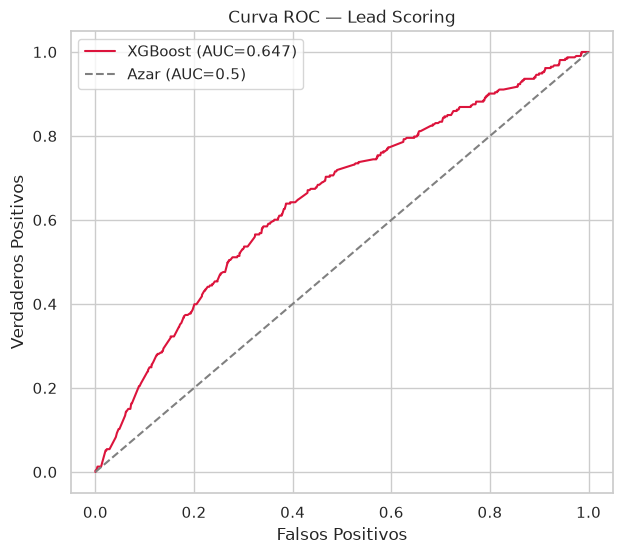

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc_test:.3f})', color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC — Lead Scoring')
plt.legend()
plt.show()

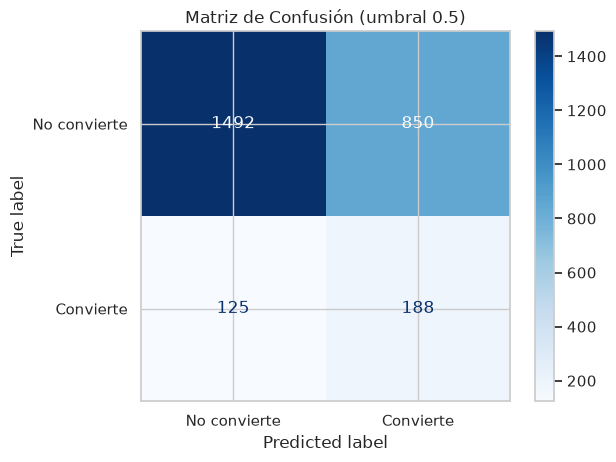

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No convierte', 'Convierte'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión (umbral 0.5)')
plt.show()

## 8. Interpretabilidad (SHAP)

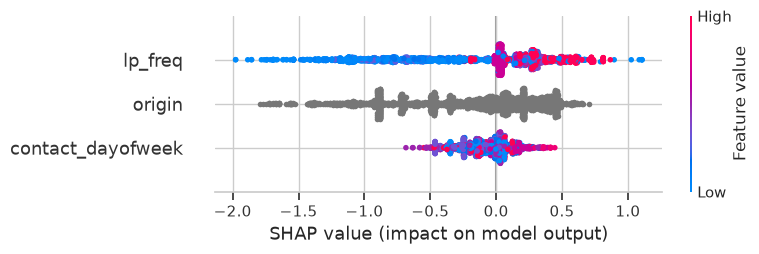

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

## 9. Guardamos el modelo

In [13]:
model_path = os.path.join(project_root, 'models', 'xgb_lead_scoring.pkl')
joblib.dump(model, model_path)
print(f"Modelo guardado en {model_path}")

Modelo guardado en ../models/xgb_lead_scoring.pkl


## 10. Resultados y limitaciones

**El hallazgo más importante de este notebook no es el modelo — es lo de la sección 2.** La primera versión marcaba `contact_month` como la feature más importante y lo leía como estacionalidad comercial; en realidad era censura del período de recolección (`won_date` no registra nada antes de dic-2017, así que los leads de 2017 casi no "convierten" en el dataset aunque hayan convertido en la realidad). Corregirlo — acotar a 2018 y pasar a split temporal — bajó el AUC de test de 0.718 a **0.647**. Es un modelo peor en el papel, pero uno que mide algo real: una feature con importancia sospechosamente alta suele ser señal de que algo anda mal con los datos, no de que el modelo es mejor.

**AUC-ROC: 0.647 en test** (leads de abril-mayo 2018; contra 0.5 de un modelo al azar), con hiperparámetros (`max_depth=4, min_child_weight=10, reg_lambda=5`) elegidos por `GridSearchCV` y 5-fold `StratifiedKFold` sobre train (enero-marzo 2018; AUC de CV: 0.656). Que CV y test queden cerca (0.656 vs. 0.647) es razonable tratándose de dos períodos de tiempo distintos.

Por SHAP, el orden de importancia pasa a ser `lp_freq` > `origin` > `contact_dayofweek` — sin el ruido de `contact_month`, la popularidad de la landing page queda como la señal dominante, seguida de cerca por el canal de origen. La dirección de `origin` se mantiene igual que en la versión anterior: `paid_search` empuja hacia conversión, mientras que `email` y `other` empujan fuerte en contra.

**Limitaciones a tener en cuenta:**
- El target sigue siendo "convirtió a seller", no "convirtió en un seller que factura mucho" (ver sección 1).
- Precision de la clase positiva: 0.18, casi igual a la versión anterior, pero el recall baja a 0.60 y la tasa base de test es más baja (11.8% vs. el 10.5% de antes) — el lift real es de ~1.5x.
- Acotar a 2018 deja afuera ~2.000 leads de 2017 — no porque no sirvan, sino porque no hay forma honesta de saber si convirtieron dentro de la ventana de datos disponible. Más historia post-2017 permitiría reincorporarlos.
- Candidato natural para una v2: sumar features de comportamiento del lead (hoy solo hay canal/origen) una vez que haya más datos históricos, y repetir este chequeo de censura con cualquier feature temporal nueva antes de confiar en su importancia.